# E14 Isotropic Curvature Spectrum-Control Experiment

### Problem

This notebook is a controlled one-step experiment for the isotropic-curvature story. It does not train Matrix Sensing or Matrix Factorization. Instead it constructs synthetic gradient spectra and curvature growth functions, then compares update spectra directly.

The hypothesis is that full orthogonalization is not always optimal. Partial spectrum homogenization should be better in smooth curvature regimes, whereas polar orthogonalization should become competitive near phase-transition-like curvature.

## Implementation Details: Skip Unless Modifying The Experiment

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Synthetic Runs

In [2]:
NOTEBOOK_ID = "E14 isotropic curvature spectrum control"
D = 40
RANK = 10
SPECTRA = ["flat", "power", "exponential", "spiked"]
CURVATURES = ["quadratic", "polynomial", "exponential", "threshold"]
METHODS = ["gradient", "normalized", "spectral-normalized", "partial-homogenized", "polar"]
GAMMAS = [0.0, 0.25, 0.5, 0.75, 1.0]
print(f"spectra={SPECTRA}")
print(f"curvatures={CURVATURES}")


spectra=['flat', 'power', 'exponential', 'spiked']
curvatures=['quadratic', 'polynomial', 'exponential', 'threshold']


### Pseudocode

```text
construct singular values of a synthetic gradient
construct different update singular-value profiles
evaluate a one-step quadratic model: linear gain minus curvature penalty
compare which update profile has the largest predicted improvement
```

### Synthetic Objective Helpers

In [3]:
def make_singular_values(kind, rank):
    if kind == "flat":
        return np.ones(rank)
    if kind == "power":
        return np.arange(1, rank + 1, dtype=float) ** -1.0
    if kind == "exponential":
        return np.exp(-0.6 * np.arange(rank, dtype=float))
    if kind == "spiked":
        values = np.ones(rank) * 0.05
        values[0] = 1.0
        values[1] = 0.5
        return values
    raise ValueError(kind)


def curvature_weights(kind, s):
    x = s / max(np.max(s), 1e-12)
    if kind == "quadratic":
        return np.ones_like(s)
    if kind == "polynomial":
        return 1.0 + 10.0 * x**2
    if kind == "exponential":
        return np.exp(3.0 * x)
    if kind == "threshold":
        return np.where(x > 0.35, 30.0, 1.0)
    raise ValueError(kind)


def update_profile(method, s, gamma=0.5):
    if method == "gradient":
        u = s.copy()
    elif method == "normalized":
        u = s / max(np.linalg.norm(s), 1e-12)
    elif method == "spectral-normalized":
        u = s / max(np.max(s), 1e-12)
    elif method == "partial-homogenized":
        # gamma=0 is gradient-like; gamma=1 is polar-like.
        u = s ** (1.0 - gamma)
    elif method == "polar":
        u = np.ones_like(s)
    else:
        raise ValueError(method)
    return u / max(np.linalg.norm(u), 1e-12)


def predicted_improvement(s, curvature, method, gamma=0.5, radius=1.0):
    # Improvement in a local model: <G, Delta> - 0.5 * sum_i h_i * Delta_i^2.
    delta = radius * update_profile(method, s, gamma=gamma)
    h = curvature_weights(curvature, s)
    linear_gain = float(np.dot(s, delta))
    curvature_penalty = 0.5 * float(np.dot(h, delta**2))
    return linear_gain - curvature_penalty

records = []
for spectrum, curvature, method in product(SPECTRA, CURVATURES, METHODS):
    gammas = GAMMAS if method == "partial-homogenized" else [np.nan]
    for gamma in gammas:
        s = make_singular_values(spectrum, RANK)
        score = predicted_improvement(s, curvature, method, gamma=0.5 if np.isnan(gamma) else gamma)
        records.append({"spectrum": spectrum, "curvature": curvature, "method": method, "gamma": gamma, "predicted_improvement": score})
results = pd.DataFrame(records)
IPython.display.display(results)


,spectrum,curvature,method,gamma,predicted_improvement
0,flat,quadratic,gradient,NaN,2.662278
1,flat,quadratic,normalized,NaN,2.662278
2,flat,quadratic,spectral-normalized,NaN,2.662278
3,flat,quadratic,partial-homogenized,0.00,2.662278
4,flat,quadratic,partial-homogenized,0.25,2.662278
...,...,...,...,...,...
139,spiked,threshold,partial-homogenized,0.25,-12.986061
140,spiked,threshold,partial-homogenized,0.50,-10.900509
141,spiked,threshold,partial-homogenized,0.75,-6.719608
142,spiked,threshold,partial-homogenized,1.00,-2.799167


### Best Update By Curvature Regime

In [4]:
best = results.sort_values("predicted_improvement", ascending=False).groupby(["spectrum", "curvature"], as_index=False, observed=True).head(1)
IPython.display.display(best.sort_values(["spectrum", "curvature"]))


,spectrum,curvature,method,gamma,predicted_improvement
97,exponential,exponential,partial-homogenized,1.0,-1.102277
89,exponential,polynomial,polar,NaN,-0.516362
75,exponential,quadratic,partial-homogenized,0.0,0.696246
106,exponential,threshold,partial-homogenized,1.0,-2.700860
20,flat,exponential,spectral-normalized,NaN,-6.880491
12,flat,polynomial,partial-homogenized,0.0,-2.337722
0,flat,quadratic,gradient,NaN,2.662278
29,flat,threshold,spectral-normalized,NaN,-11.837722
62,power,exponential,polar,NaN,-1.004223
53,power,polynomial,polar,NaN,-0.348663


### Improvement Curves

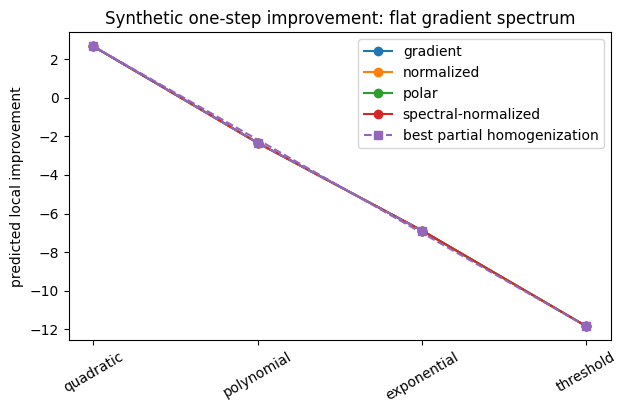

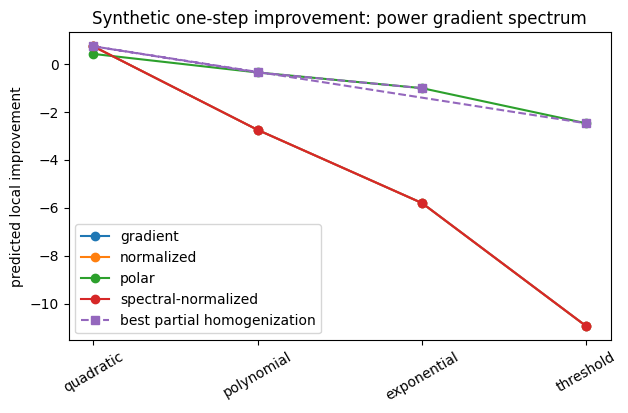

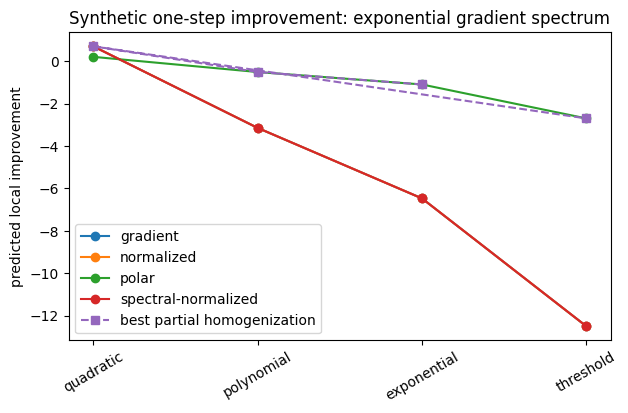

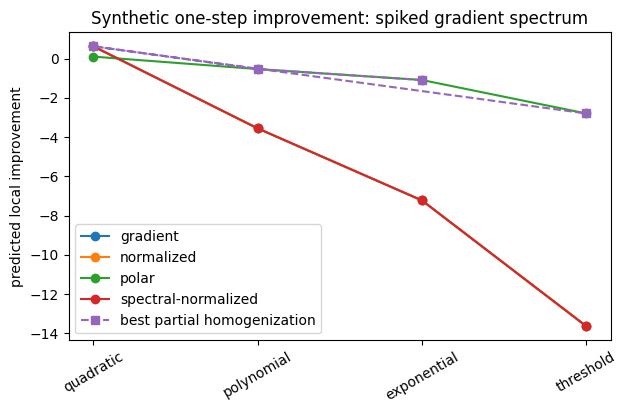

In [5]:
for spectrum in SPECTRA:
    fig, ax = plt.subplots(figsize=(7, 4))
    sub = results[(results["spectrum"] == spectrum) & (results["method"] != "partial-homogenized")]
    for method, group in sub.groupby("method", observed=True):
        ax.plot(group["curvature"], group["predicted_improvement"], marker="o", label=method)
    partial = results[(results["spectrum"] == spectrum) & (results["method"] == "partial-homogenized")].groupby("curvature", as_index=False, observed=True)["predicted_improvement"].max()
    ax.plot(partial["curvature"], partial["predicted_improvement"], marker="s", linestyle="--", label="best partial homogenization")
    ax.set_title(f"Synthetic one-step improvement: {spectrum} gradient spectrum")
    ax.set_ylabel("predicted local improvement")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    plt.show()


### Reading The Result

This experiment supports the isotropic-curvature story if the best update depends on curvature regime. Full polar orthogonalization should not dominate every regime; it should become most competitive in threshold-like curvature, while partial homogenization can be better under smooth curvature growth.